In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("student-mat.csv", sep=";")

In [3]:
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
#Check missing values 
data.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
#check for duplicates
data = data.drop_duplicates()

In [6]:
#rule defining 
data["Pass_Fail"] = data["G3"].apply(lambda x: 1 if x >= 10 else 0)

In [7]:
import pandas as pd

# One-hot encode categorical variables
data_encoded = pd.get_dummies(data, drop_first=True)

In [9]:
#feature and target for model A - early risk detection
X_A = data_encoded.drop(["Pass_Fail", "G2", "G3"], axis=1)
y_A = data_encoded["Pass_Fail"]

In [10]:
#train test data splitting for model A - early risk detection
from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42
)

In [11]:
#scaling for model A - early risk detection
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# ---------- Model A (Early) ----------
X_A_train_scaled = scaler.fit_transform(X_A_train)
X_A_test_scaled  = scaler.transform(X_A_test)

In [12]:
#feature and target for model B - late risk detection
X_B = data_encoded.drop(["Pass_Fail", "G3"], axis=1)
y_B = data_encoded["Pass_Fail"]

In [13]:
#train test data splitting for model B - late risk detection
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42
)

In [14]:
#scaling for model B - late risk detection
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# ---------- Model B (Late) ----------
X_B_train_scaled = scaler.fit_transform(X_B_train)
X_B_test_scaled  = scaler.transform(X_B_test)

In [24]:
#logistic regression for model A
from sklearn.linear_model import LogisticRegression

model_A_lr = LogisticRegression(max_iter=1000)
model_A_lr.fit(X_A_train_scaled, y_A_train)
y_A_pred = model_A_lr.predict(X_A_test_scaled)

In [25]:
#logistic regression for model B
from sklearn.linear_model import LogisticRegression

model_B_lr = LogisticRegression(max_iter=1000)
model_B_lr.fit(X_B_train_scaled, y_B_train)
y_B_pred = model_B_lr.predict(X_B_test_scaled)

In [26]:
#print results for model A
from sklearn.metrics import classification_report, accuracy_score

print("Model A - Early Risk Detection")
print("Accuracy:", accuracy_score(y_A_test, y_A_pred))
print(classification_report(y_A_test, y_A_pred))

Model A - Early Risk Detection
Accuracy: 0.8481012658227848
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        27
           1       0.88      0.88      0.88        52

    accuracy                           0.85        79
   macro avg       0.83      0.83      0.83        79
weighted avg       0.85      0.85      0.85        79



In [23]:
#print results for model B
from sklearn.metrics import classification_report, accuracy_score

print("Model B - Late Risk Detection")
print("Accuracy:", accuracy_score(y_B_test, y_B_pred))
print(classification_report(y_B_test, y_B_pred))

Model B - Late Risk Detection
Accuracy: 0.8987341772151899
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       0.94      0.90      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



In [27]:
print("Early Model Accuracy:", accuracy_score(y_A_test, y_A_pred))
print("Late Model Accuracy:", accuracy_score(y_B_test, y_B_pred))

Early Model Accuracy: 0.8481012658227848
Late Model Accuracy: 0.8987341772151899


In [28]:
#random forest initiation 
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_A = RandomForestClassifier(random_state=42)
rf_A.fit(X_A_train, y_A_train)

y_A_rf_pred = rf_A.predict(X_A_test)

rf_B = RandomForestClassifier(random_state=42)
rf_B.fit(X_B_train, y_B_train)

y_B_rf_pred = rf_B.predict(X_B_test)

In [30]:
#print results for model A
print("Model A - Early Risk Detection (Random Forest)")
print("Accuracy:", accuracy_score(y_A_test, y_A_rf_pred))
print(classification_report(y_A_test, y_A_rf_pred))

Model A - Early Risk Detection (Random Forest)
Accuracy: 0.8227848101265823
              precision    recall  f1-score   support

           0       0.76      0.70      0.73        27
           1       0.85      0.88      0.87        52

    accuracy                           0.82        79
   macro avg       0.81      0.79      0.80        79
weighted avg       0.82      0.82      0.82        79



In [32]:
#print results for model B
print("Model B - Late Risk Detection (Random Forest)")
print("Accuracy:", accuracy_score(y_B_test, y_B_rf_pred))
print(classification_report(y_B_test, y_B_rf_pred))

Model B - Late Risk Detection (Random Forest)
Accuracy: 0.9240506329113924
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



In [34]:
print("Early Model Accuracy:", accuracy_score(y_A_test, y_A_rf_pred))
print("Late Model Accuracy:", accuracy_score(y_B_test, y_B_rf_pred))

Early Model Accuracy: 0.8227848101265823
Late Model Accuracy: 0.9240506329113924


In [35]:
from sklearn.metrics import accuracy_score

print("=== MODEL COMPARISON ===")
print("Early - Logistic Regression:", accuracy_score(y_A_test, y_A_pred))
print("Early - Random Forest:", accuracy_score(y_A_test, y_A_rf_pred))
print("Late - Logistic Regression:", accuracy_score(y_B_test, y_B_pred))
print("Late - Random Forest:", accuracy_score(y_B_test, y_B_rf_pred))

=== MODEL COMPARISON ===
Early - Logistic Regression: 0.8481012658227848
Early - Random Forest: 0.8227848101265823
Late - Logistic Regression: 0.8987341772151899
Late - Random Forest: 0.9240506329113924


In [36]:
#roc scores 
from sklearn.metrics import roc_auc_score

# Logistic Regression
roc_auc_lr_A = roc_auc_score(y_A_test, model_A_lr.predict_proba(X_A_test_scaled)[:,1])
roc_auc_lr_B = roc_auc_score(y_B_test, model_B_lr.predict_proba(X_B_test_scaled)[:,1])

# Random Forest
roc_auc_rf_A = roc_auc_score(y_A_test, rf_A.predict_proba(X_A_test)[:,1])
roc_auc_rf_B = roc_auc_score(y_B_test, rf_B.predict_proba(X_B_test)[:,1])

print("=== ROC-AUC Scores ===")
print("Early - Logistic Regression:", roc_auc_lr_A)
print("Early - Random Forest:", roc_auc_rf_A)
print("Late - Logistic Regression:", roc_auc_lr_B)
print("Late - Random Forest:", roc_auc_rf_B)

=== ROC-AUC Scores ===
Early - Logistic Regression: 0.9280626780626781
Early - Random Forest: 0.9184472934472935
Late - Logistic Regression: 0.9736467236467237
Late - Random Forest: 0.9529914529914529


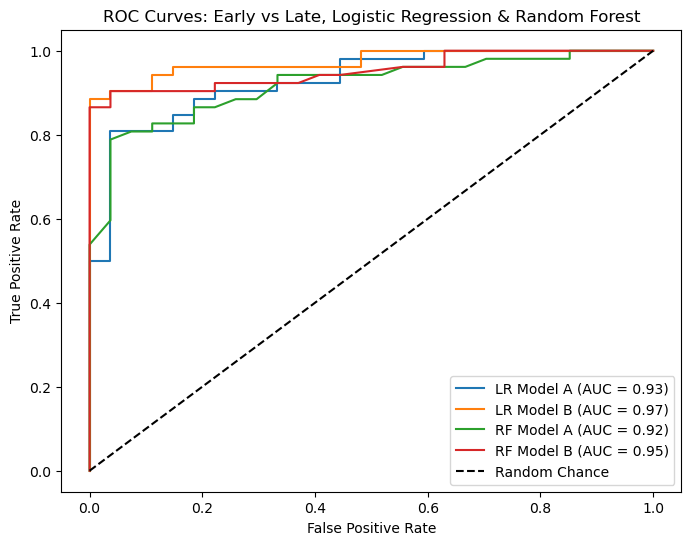

In [37]:
#roc curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Function to plot ROC curve for one model
def plot_roc(y_true, y_probs, label_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label_name} (AUC = {roc_auc:.2f})')

plt.figure(figsize=(8,6))

# Logistic Regression
plot_roc(y_A_test, model_A_lr.predict_proba(X_A_test_scaled)[:,1], "LR Model A")
plot_roc(y_B_test, model_B_lr.predict_proba(X_B_test_scaled)[:,1], "LR Model B")

# Random Forest
plot_roc(y_A_test, rf_A.predict_proba(X_A_test)[:,1], "RF Model A")
plot_roc(y_B_test, rf_B.predict_proba(X_B_test)[:,1], "RF Model B")

# Random chance line
plt.plot([0,1], [0,1], 'k--', label="Random Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Early vs Late, Logistic Regression & Random Forest")
plt.legend(loc="lower right")
plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_A = RandomForestClassifier(random_state=42)
rf_B = RandomForestClassifier(random_state=42)

In [39]:
# Train Random Forest models
rf_A.fit(X_A_train, y_A_train)
rf_B.fit(X_B_train, y_B_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


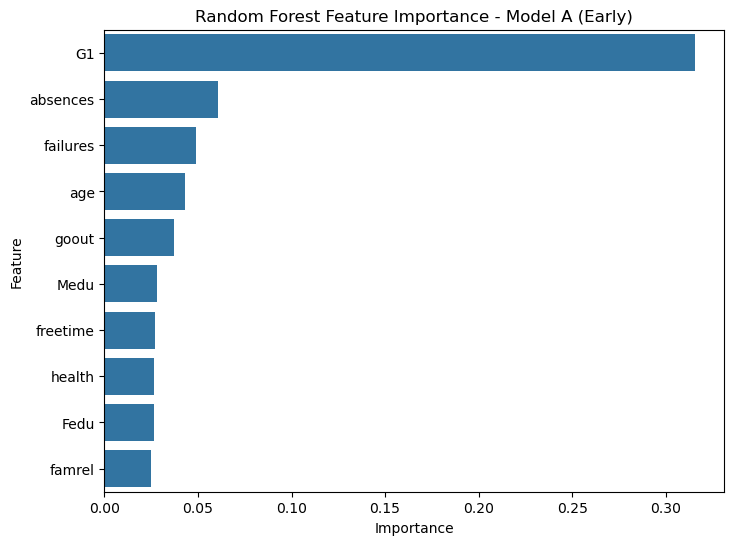

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importance from Random Forest
feat_imp_A = pd.Series(rf_A.feature_importances_, index=X_A_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp_A.values, y=feat_imp_A.index)
plt.title("Random Forest Feature Importance - Model A (Early)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

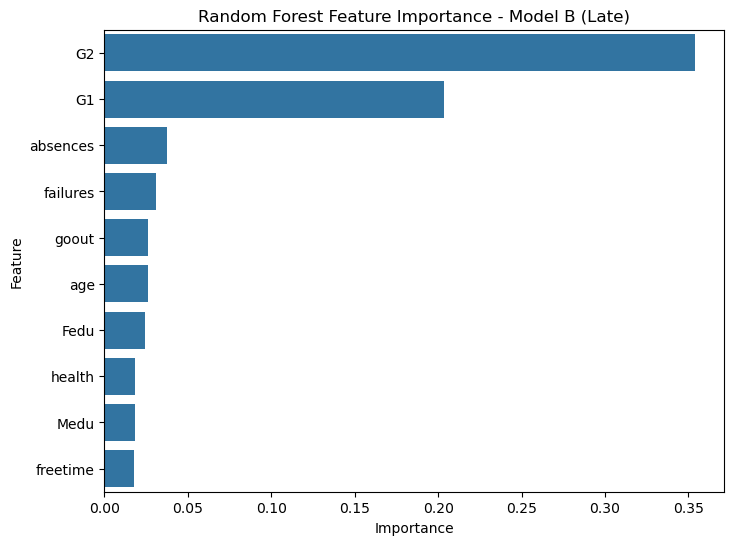

In [41]:
feat_imp_B = pd.Series(rf_B.feature_importances_, index=X_B_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp_B.values, y=feat_imp_B.index)
plt.title("Random Forest Feature Importance - Model B (Late)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression

# Early detection
model_A_lr = LogisticRegression(max_iter=1000, random_state=42)

# Late detection
model_B_lr = LogisticRegression(max_iter=1000, random_state=42)

In [43]:
# Model A (Early) training
model_A_lr.fit(X_A_train, y_A_train)

# Model B (Late) training
model_B_lr.fit(X_B_train, y_B_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
# Model A (Early)
coef_A = pd.DataFrame({
    "Feature": X_A.columns,
    "Coefficient": model_A_lr.coef_[0]
})

# Sort by absolute value to see most influential features
coef_A["Abs_Coefficient"] = coef_A["Coefficient"].abs()
coef_A = coef_A.sort_values(by="Abs_Coefficient", ascending=False)
coef_A.head(10)  # Top 10 features

,Feature,Coefficient,Abs_Coefficient
24,Fjob_other,1.274093,1.274093
13,G1,1.259988,1.259988
22,Mjob_teacher,-0.973948,0.973948
34,paid_yes,0.929850,0.929850
39,romantic_yes,-0.866966,0.866966
23,Fjob_health,-0.848767,0.848767
18,Pstatus_T,-0.746221,0.746221
0,age,-0.661830,0.661830
28,reason_other,0.597455,0.597455
29,reason_reputation,0.555973,0.555973


In [45]:
# Model B (Late)
coef_B = pd.DataFrame({
    "Feature": X_B.columns,
    "Coefficient": model_B_lr.coef_[0]
})

coef_B["Abs_Coefficient"] = coef_B["Coefficient"].abs()
coef_B = coef_B.sort_values(by="Abs_Coefficient", ascending=False)
coef_B.head(10)

,Feature,Coefficient,Abs_Coefficient
14,G2,2.192561,2.192561
25,Fjob_other,1.288610,1.288610
21,Mjob_other,-1.210652,1.210652
6,famrel,0.938927,0.938927
18,famsize_LE3,-0.914015,0.914015
0,age,-0.841027,0.841027
36,activities_yes,-0.708755,0.708755
4,studytime,-0.691948,0.691948
26,Fjob_services,-0.660729,0.660729
16,sex_M,-0.556237,0.556237


In [59]:
# Convert scaled test array to DataFrame with proper column names
X_B_test_df = pd.DataFrame(X_B_test_scaled, columns=X_B_train.columns)

# Now predict probabilities for first student
student_prob = model_B_lr.predict_proba(X_B_test_df.iloc[[0]])  # keep as 2D array
print("Probability of Fail:", round(student_prob[0][0], 3))
print("Probability of Pass:", round(student_prob[0][1], 3))

Probability of Fail: 1.0
Probability of Pass: 0.0


In [60]:
X_A_test_df = pd.DataFrame(X_A_test_scaled, columns=X_A_train.columns)
student_prob = model_A_lr.predict_proba(X_A_test_df.iloc[[0]])
print("Probability of Fail:", round(student_prob[0][0], 3))
print("Probability of Pass:", round(student_prob[0][1], 3))

Probability of Fail: 0.298
Probability of Pass: 0.702
